# Information Content, Degrees of Freedom, and Vertical resolution

## Python imports 

RUN THIS WITH AND WITHOUT NORMING

In [2]:
import numpy as np 
from numba import njit 
import scipy.constants as spc
import matplotlib.pyplot as plt 
from matplotlib import ticker 
from tqdm.auto import tqdm 

import sys
sys.path.append('..')
import eccm 
import mrtm

plt.style.use('~/Documents/Research/Akins.mplstyle')
%matplotlib widget

## Helper functions 

In [15]:
def degrees_of_freedom(ev): 
    ds = np.sum(ev**2 / (1 + ev**2))
    dn = np.sum(1 / (1 + ev**2))
    return ds, dn 

def shannon_information(ev): 
    H = 0.5 * np.sum(np.log(1 + ev**2))
    return H 

@njit(fastmath=True)
def get_BG_average(K, z):
    # Backus Gilbert averaging kernel, returns averaging kernel and spread 
    # K should be nmeas*nvert
    
    kvec = np.empty(len(K))
    for i, krow in enumerate(K): 
        kvec[i] = np.trapz(krow, z)
    kvec = kvec[:, np.newaxis]
    
    a = np.empty(K.shape)
    
    for i, zz in enumerate(z): 
        Rkl = np.zeros((K.shape[0], K.shape[0]))
        for k, kk in enumerate(K): 
            for l, ll in enumerate(K): 
                Rkl[k, l] = 12 * np.trapz((zz - z)**2 * kk * ll, z)
        Rinv = np.linalg.pinv(Rkl)
        a[:, i] = ((Rinv @ kvec) / (kvec.T @ Rinv @ kvec)).ravel()
    
    A = np.zeros((len(z), len(z)))
    for i, zz in enumerate(z): 
        for j, zzz in enumerate(z): 
            A[i, j] = np.sum(a[:, i] * K[:, j])
            
    return A

@njit(fastmath=True)
def get_BG_spread(K, z):
    # Backus Gilbert spread metric
    # K should be nmeas*nvert
    
    kvec = np.empty(len(K))
    for i, krow in enumerate(K): 
        kvec[i] = np.trapz(krow, z)
    kvec = kvec[:, np.newaxis]
    
    s = np.empty((1, len(z)))
    
    for i, zz in enumerate(z): 
        Rkl = np.zeros((K.shape[0], K.shape[0]))
        for k, kk in enumerate(K): 
            for l, ll in enumerate(K): 
                Rkl[k, l] = 12 * np.trapz((zz - z)**2 * kk * ll, z)
        Rinv = np.linalg.pinv(Rkl)
        s[:, i] = (1 / (kvec.T @ Rinv @ kvec)).ravel()
 
    return s.ravel()

## Saturn

In [16]:
Tsys = 1000 
tint = 1  # s
T_1s = 20  # K
abscal = 0.02  # From Juno, Janssen


p_grid = np.logspace(2, 9, 10000)
saturn_gravity = 10.44  # m/s2 
planet_radius = 60268  # km 

# Reference case
saturn_ro = np.loadtxt('../data/ro_profiles/saturn_cassini_schinder2011.txt', skiprows=3, delimiter=',')
saturn_pressure = saturn_ro[:, 0] * 1e2  # Pa
saturn_temperature = saturn_ro[:, 1]


gases1 = eccm.solar_to_deep_mole_fraction(10) 
gases2 = eccm.solar_to_deep_mole_fraction(3) 
deep_h2o = gases1['H2O']
deep_nh3 = gases2['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases1['CH4']
deep_ph3 = gases1['PH3']
h2o_rh = 0.7
h2s_rh = 0.7

pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, saturn_pressure, saturn_temperature, saturn_gravity,
                                                 deep_h2o, deep_nh3, deep_h2s, deep_ch4, deep_ph3, 0.88, 0.12,
                                                 nh3_rh = 0.7, h2o_rh = 0.7,
                                                 latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)

minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)

S_a = np.diag(T_1s**2 * np.ones(temperature_grid[slc].shape)) 

# Make a list of all possible combinations of channels (5% < BW < 25%, lower bound is 1 ch.)
N = 2
cbw = 0.25
freq_list = [] 
BW_list = [] 
cbw_list = [] 
while cbw >= 0.05: 
    freq_ghz = np.logspace(np.log10(0.1), np.log10(100), N) # GHz 
    BWG = np.gradient(freq_ghz)
    BWF = 0.25 * freq_ghz 
    BW = np.minimum(BWF, BWG)
    # Update the decision criteria
    amin = np.argmin(BW)
    cbw = BW[amin] / freq_ghz[amin]
    cbw_list.append(cbw)
    freq_list.append(freq_ghz)
    BW_list.append(BW)
    N += 1 

# Don't need all of these 
cbwr = np.arange(0.05, 0.25, 0.01)[::-1]
cbwl = np.array(cbw_list)
dexs = list(np.argwhere(cbwl == 0.25).ravel())
for cb in cbwr: 
    dexs.append(np.argmin(abs(cbwl - cb)))

cbw_list = list(cbwl[dexs])
freq_list = [freq_list[i] for i in dexs]
BW_list = [BW_list[i] for i in dexs]

# Make a list of all incidence angle combinations 
incang_list = [np.linspace(0, 60, N) for N in range(1, 8)]

ds_list = np.zeros((len(freq_list), len(incang_list)))
dn_list = np.zeros((len(freq_list), len(incang_list)))
H_list = np.zeros((len(freq_list), len(incang_list)))
spread_list = np.zeros((len(freq_list), len(incang_list), len(temperature_grid[slc])))

for i, fl in enumerate(tqdm(freq_list, position=0)): 
    BW = BW_list[i]
    NEDT = Tsys / np.sqrt(tint * BW * 1e9)
    for j, ial in enumerate(tqdm(incang_list, position=1)): 
        weights = []
        error_comp = []  
        for k, incang in enumerate(ial): 
            full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(fl, incang, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)
            weights.append(weight_up)
            if k == 0: 
                # Absolute nadir TB error
                error_comp.append(Tup * abscal + NEDT)
            else: 
                # Relative angle error 
                error_comp.append(NEDT)

        K = np.vstack(weights)
        S_e = np.diag(np.concatenate(error_comp)) 
        tK = np.linalg.pinv(np.sqrt(S_e)) @ K @ np.sqrt(S_a)
        U, s, vh = np.linalg.svd(tK)
        ds, dn = degrees_of_freedom(s)
        H = shannon_information(s)
        sz = get_BG_spread(K.copy(), pressure_grid[slc].copy())
        ds_list[i, j] = ds
        dn_list[i, j] = dn
        H_list[i, j] = H
        spread_list[i, j] = sz

chan_num = np.array([len(x) for x in freq_list])
ang_num = np.array([len(x) for x in incang_list])
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list, 'spread_list': spread_list, 'pressure_grid_Pa': pressure_grid[slc]}
import pickle
pickle.dump(tdict, open('saturn_info_analysis.p', 'wb'))

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
print(K.shape)
print(pressure_grid[slc].shape)

(2, 3333)
(3333,)


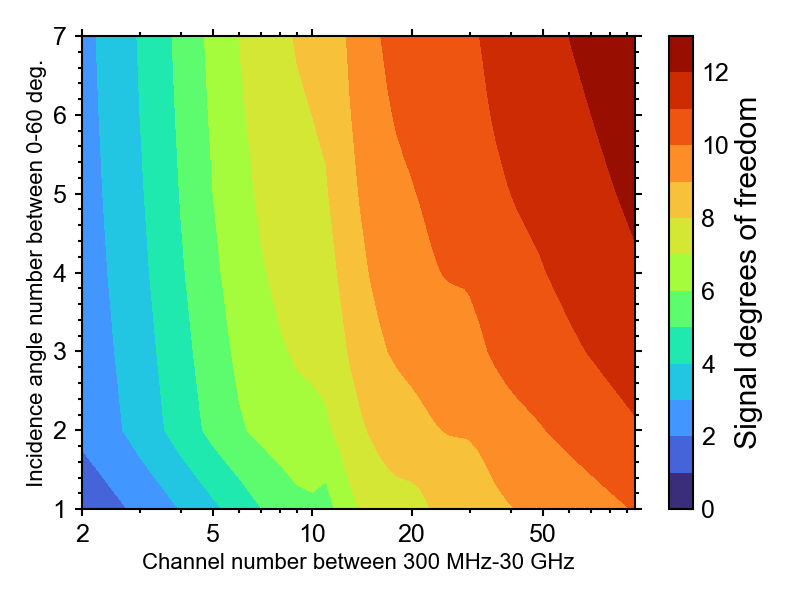

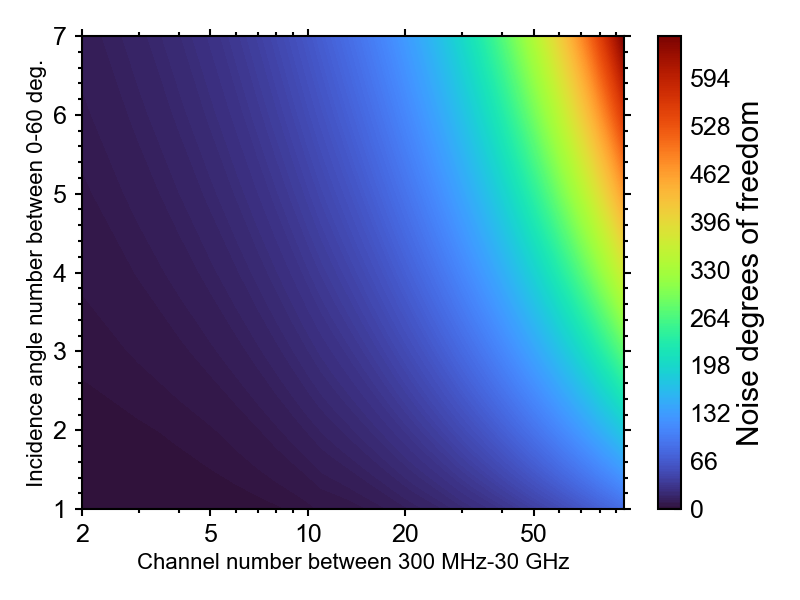

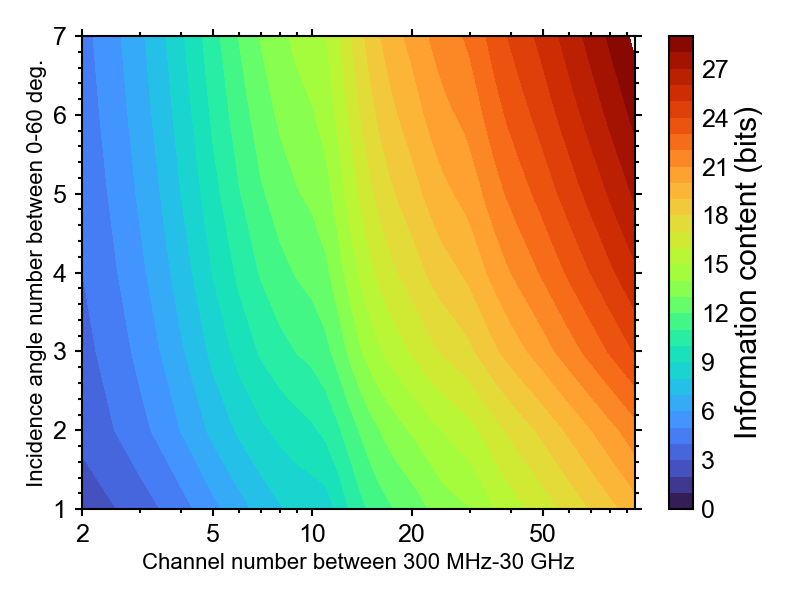

In [ ]:
tdict = pickle.load(open('saturn_info_analysis.p', 'rb'))
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list}
chan_num = tdict['chan_num']
ang_num = tdict['ang_num']
ds_list = tdict['ds_list']
dn_list = tdict['dn_list']
H_list = tdict['H_list']

plt.figure()
plt.contourf(chan_num, ang_num, ds_list.T, cmap='turbo', levels=np.arange(np.round(np.max(ds_list))+1))
plt.xscale('log')
plt.colorbar(label='Signal degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_deg_signal.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, dn_list.T, cmap='turbo', levels=np.arange(np.round(np.max(dn_list))+1))
plt.xscale('log')
plt.colorbar(label='Noise degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_deg_noise.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, H_list.T, cmap='turbo', levels=np.arange(np.round(np.max(H_list))+1))
plt.xscale('log')
plt.colorbar(label='Information content (bits)')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('saturn_info_content.png', dpi=300)

## Uranus 

In [7]:
def degrees_of_freedom(ev): 
    ds = np.sum(ev**2 / (1 + ev**2))
    dn = np.sum(1 / (1 + ev**2))
    return ds, dn 

def shannon_information(ev): 
    H = 0.5 * np.sum(np.log(1 + ev**2))
    return H 

Tsys = 1000 
tint = 100e-3  # s
T_1s = 20  # K

p_grid = np.logspace(2, 9, 10000)
uranus_gravity = 8.87  # m/s2 
planet_radius = 25559  # km 

uranus_ro = np.loadtxt('../data/ro_profiles/uranus_voyager2_lindal1987.txt', skiprows=3, delimiter=',')
uranus_pressure = uranus_ro[:, 0] * 1e2  # Pa
uranus_temperature = uranus_ro[:, 1]

gases1 = eccm.solar_to_deep_mole_fraction(35) 
gases2 = eccm.solar_to_deep_mole_fraction(50) 
gases3 = eccm.solar_to_deep_mole_fraction(1) 

deep_h2o = gases1['H2O']
deep_nh3 = gases3['NH3']
deep_h2s = gases1['H2S']
deep_ch4 = gases2['CH4']


pressure_grid, temperature_grid, altitude_grid, \
x_h2o, x_nh3, x_h2s, x_ch4, x_ph3, x_h2, x_he, \
a_h2osolid, a_h2oliquid, a_h2osolution, \
a_nh3solid, a_nh3liquid, \
a_h2ssolid, a_h2sliquid, \
a_nh4sh, c_nh3h2o, \
a_ch4solid, a_ch4liquid, a_ph3solid  = eccm.eccm(p_grid, uranus_pressure, uranus_temperature, uranus_gravity,
                                                 gases1['H2O'], gases3['NH3'], gases1['H2S'], gases2['CH4'], 0., 0.85, 0.15,
                                                 h2s_rh=0.35, h2o_rh=0.35, latent_heat_update=True, force_reference_above_pressure=1.*spc.bar)


minloc = np.argmin(abs(pressure_grid / spc.bar - 1e-3))
maxloc = np.argmin(abs(pressure_grid / spc.bar - 1000e3))
slc = slice(maxloc, minloc, 3)

S_a = np.diag(T_1s**2 * np.ones(temperature_grid[slc].shape)) 

# Make a list of all possible combinations of channels (5% < BW < 25%, lower bound is 1 ch.)
N = 2
cbw = 0.25
freq_list = [] 
BW_list = [] 
cbw_list = [] 
while cbw >= 0.05: 
    freq_ghz = np.logspace(np.log10(0.3), np.log10(30), N) # GHz 
    BWG = np.gradient(freq_ghz)
    BWF = 0.25 * freq_ghz 
    BW = np.minimum(BWF, BWG)
    # Update the decision criteria
    amin = np.argmin(BW)
    cbw = BW[amin] / freq_ghz[amin]
    cbw_list.append(cbw)
    freq_list.append(freq_ghz)
    BW_list.append(BW)
    N += 1 

# Don't need all of these 
cbwr = np.arange(0.05, 0.25, 0.01)[::-1]
cbwl = np.array(cbw_list)
dexs = list(np.argwhere(cbwl == 0.25).ravel())
for cb in cbwr: 
    dexs.append(np.argmin(abs(cbwl - cb)))

cbw_list = list(cbwl[dexs])
freq_list = [freq_list[i] for i in dexs]
BW_list = [BW_list[i] for i in dexs]

# Make a list of all incidence angle combinations 
incang_list = [np.linspace(0, 60, N) for N in range(1, 8)]

ds_list = np.zeros((len(freq_list), len(incang_list)))
dn_list = np.zeros((len(freq_list), len(incang_list)))
H_list = np.zeros((len(freq_list), len(incang_list)))

for i, fl in enumerate(tqdm(freq_list, position=0)): 
    BW = BW_list[i]
    NEDT = Tsys / np.sqrt(tint * BW * 1e9)
    for j, ial in enumerate(tqdm(incang_list, position=1)): 
        weights = [] 
        for incang in ial: 
            full_tau, weight_up, weight_limb, Tup, Tlimb = mrtm.mrtm(fl, incang, altitude_grid[slc], pressure_grid[slc], temperature_grid[slc], x_h2o[slc], x_nh3[slc], x_h2s[slc], x_ch4[slc], x_ph3[slc], x_h2[slc], x_he[slc], planet_radius)

            weights.append(weight_up)
        K = np.vstack(weights)
        S_e = np.diag(1**2 * np.ones(len(K))) 
        tK = np.linalg.pinv(np.sqrt(S_e)) @ K @ np.sqrt(S_a)
        U, s, vh = np.linalg.svd(tK)
        ds, dn = degrees_of_freedom(s)
        H = shannon_information(s)
        ds_list[i, j] = ds
        dn_list[i, j] = dn
        H_list[i, j] = H

chan_num = np.array([len(x) for x in freq_list])
ang_num = np.array([len(x) for x in incang_list])
tdict = {'chan_num': chan_num, 'ang_num': ang_num, 'ds_list': ds_list, 'dn_list': dn_list, 'H_list': H_list}
import pickle
pickle.dump(tdict, open('uranus_info_analysis.p', 'wb'))

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

...

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:

chan_num = np.array([len(x) for x in freq_list])
ang_num = np.array([len(x) for x in incang_list])
plt.figure()
plt.contourf(chan_num, ang_num, ds_list.T, cmap='turbo', levels=np.arange(np.round(np.max(ds_list))+1))
plt.xscale('log')
plt.colorbar(label='Signal degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('deg_signal.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, dn_list.T, cmap='turbo', levels=np.arange(np.round(np.max(dn_list))+1))
plt.xscale('log')
plt.colorbar(label='Noise degrees of freedom')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('deg_noise.png', dpi=300)

plt.figure()
plt.contourf(chan_num, ang_num, H_list.T, cmap='turbo', levels=np.arange(np.round(np.max(H_list))+1))
plt.xscale('log')
plt.colorbar(label='Information content (bits)')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_xticks([2, 5, 10, 20, 50])
plt.gca().tick_params(axis='both', which='both', direction='out')
plt.xlabel('Channel number between 300 MHz-30 GHz', fontsize=16)
plt.ylabel('Incidence angle number between 0-60 deg.', fontsize=16)
plt.tight_layout()
plt.savefig('info_content.png', dpi=300)